# Master BigData UCM 2026

## 1. Datos vehículos a la venta 2025 en ES

IMPORTANTE: El dataset ha estado preparado a partir de una descarga y filtrado de datos que se realiza en el notebook

01b_lectura_datos_coches_ES_2025

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import plotnine
from plotnine import *

### Carga de datos

IMPORTANTE: Los nombres de variables no son directamente interpretables. Esencial ver el significado de los acrónimos de nombre de variable en notebook

01b_lectura_datos_coches_ES_2025

In [3]:
df= pd.read_pickle("datos_vehiculos_ES_2025.pkl")

In [4]:
df.shape

(4704, 16)

In [5]:
df.describe(include = 'all')

,Mk,Cn,Ct,Ft,m (kg),ep (KW),ec (cm3),z (Wh/km),Ewltp (g/km),"""W (mm)""","""At1 (mm)""","""At2 (mm)""",Fuel consumption,Electric range (km),total_registros,last_date
count,4704,4703,4704,4704,4704.000000,4697.000000,3805.000000,1489.000000,4700.000000,4704,4704,4704,3040.000000,1487.000000,4704.000000,4704
unique,75,1885,1,8,NaN,NaN,NaN,NaN,NaN,1,1,1,NaN,NaN,NaN,251
top,FORD,TRANSIT CUSTOM,M1,petrol,NaN,NaN,NaN,NaN,NaN,W (mm),At1 (mm),At2 (mm),NaN,NaN,NaN,2025-12-30
freq,534,154,4704,1877,NaN,NaN,NaN,NaN,NaN,4704,4704,4704,NaN,NaN,NaN,1139
mean,NaN,NaN,NaN,NaN,1824.764031,137.351501,1868.005256,180.971793,114.580000,NaN,NaN,NaN,5.835329,294.581708,254.350765,NaN
std,NaN,NaN,NaN,NaN,393.620874,86.976351,719.508028,36.669081,78.465132,NaN,NaN,NaN,2.544516,205.321489,894.690849,NaN
min,NaN,NaN,NaN,NaN,865.000000,8.000000,998.000000,16.000000,0.000000,NaN,NaN,NaN,0.300000,12.000000,1.000000,NaN
25%,NaN,NaN,NaN,NaN,1510.000000,91.000000,1490.000000,156.000000,32.000000,NaN,NaN,NaN,4.900000,78.000000,3.000000,NaN
50%,NaN,NaN,NaN,NaN,1775.000000,110.000000,1950.000000,175.000000,129.000000,NaN,NaN,NaN,5.800000,324.000000,14.000000,NaN
75%,NaN,NaN,NaN,NaN,2141.250000,147.000000,1997.000000,199.000000,165.000000,NaN,NaN,NaN,7.200000,476.000000,96.000000,NaN


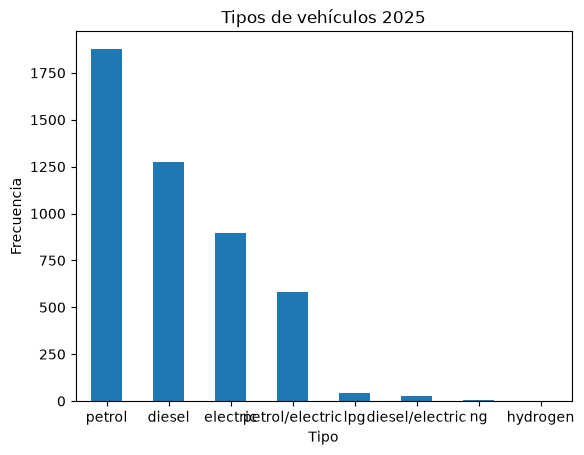

In [6]:
count_classes = df['Ft'].value_counts(sort = True)
count_classes.plot(kind = 'bar', rot=0)
plt.title("Tipos de vehículos 2025")
plt.xlabel("Tipo")
plt.ylabel("Frecuencia");

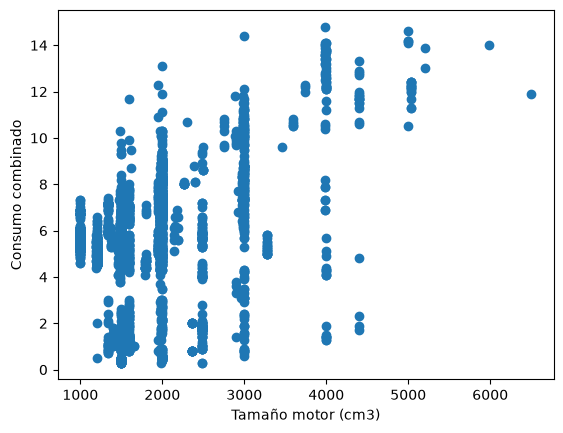

In [7]:
plt.scatter(df['ec (cm3)'], 
            df['Fuel consumption'])

plt.xlabel('Tamaño motor (cm3)')
plt.ylabel('Consumo combinado')
plt.show()

# 2. Visualizaciones con ggplot

Además del contenido recogido en la docu. teórica, es aconsejable seguir este excelente (y práctico) tutorial:

https://realpython.com/ggplot-python/


## 2.1 Scatterplot dataset vehículos



/home/pedro/Escritorio/UCM_2026/entorno_julio/lib/python3.12/site-packages/plotnine/layer.py:374: PlotnineWarning: geom_point : Removed 1664 rows containing missing values.


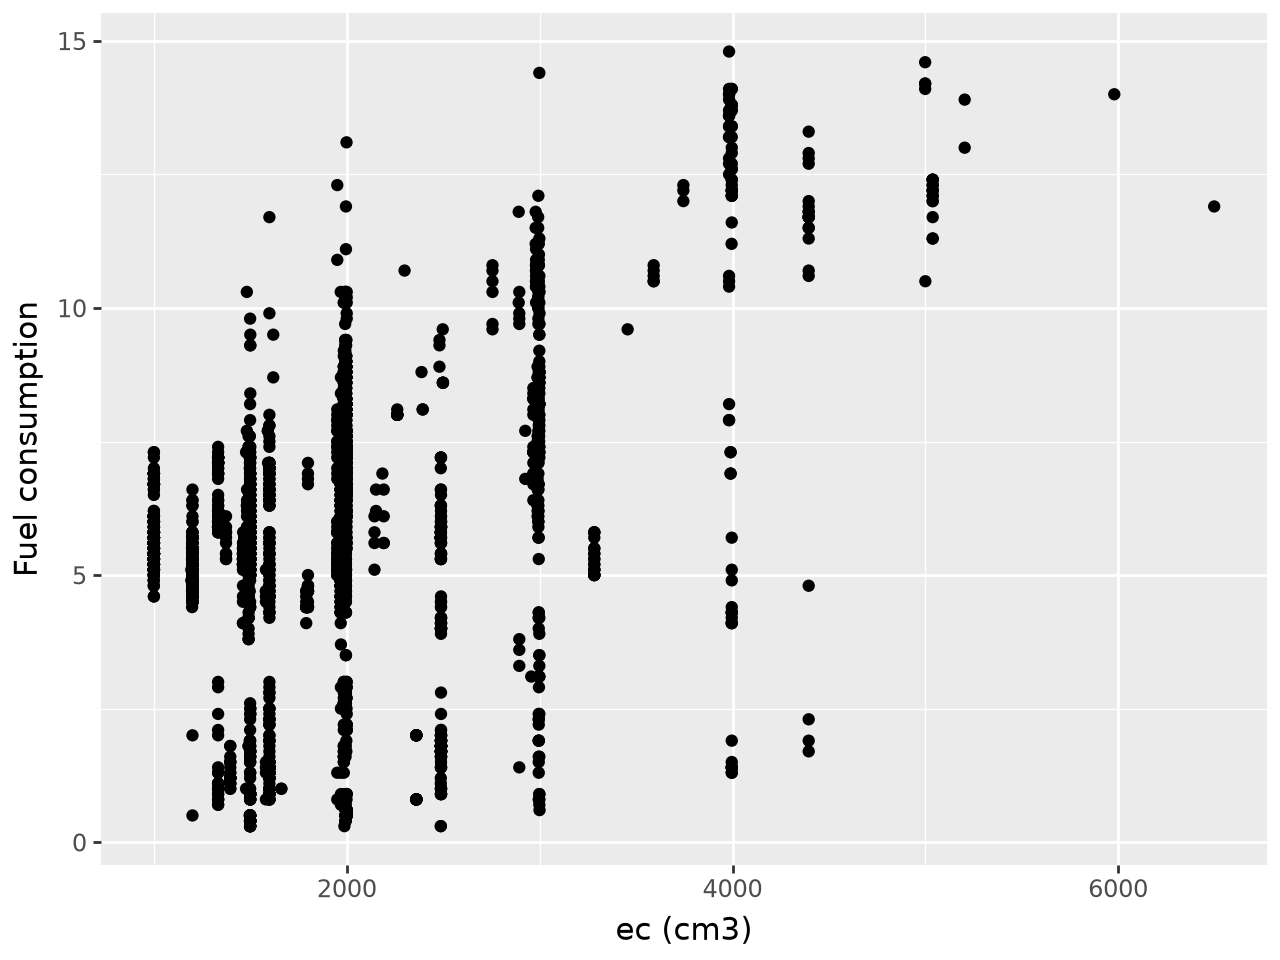

In [8]:
(
    ggplot(df)  # What data to use
    + aes(x = 'ec (cm3)', 
          y = 'Fuel consumption')  # What variable to use
    + geom_point()   # Geometric object to use for drawing
)

/home/pedro/Escritorio/UCM_2026/entorno_julio/lib/python3.12/site-packages/plotnine/stats/smoothers.py:342: PlotnineWarning: Confidence intervals are not yet implemented for lowess smoothings.
/home/pedro/Escritorio/UCM_2026/entorno_julio/lib/python3.12/site-packages/statsmodels/nonparametric/smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
/home/pedro/Escritorio/UCM_2026/entorno_julio/lib/python3.12/site-packages/plotnine/layer.py:374: PlotnineWarning: geom_point : Removed 1664 rows containing missing values.


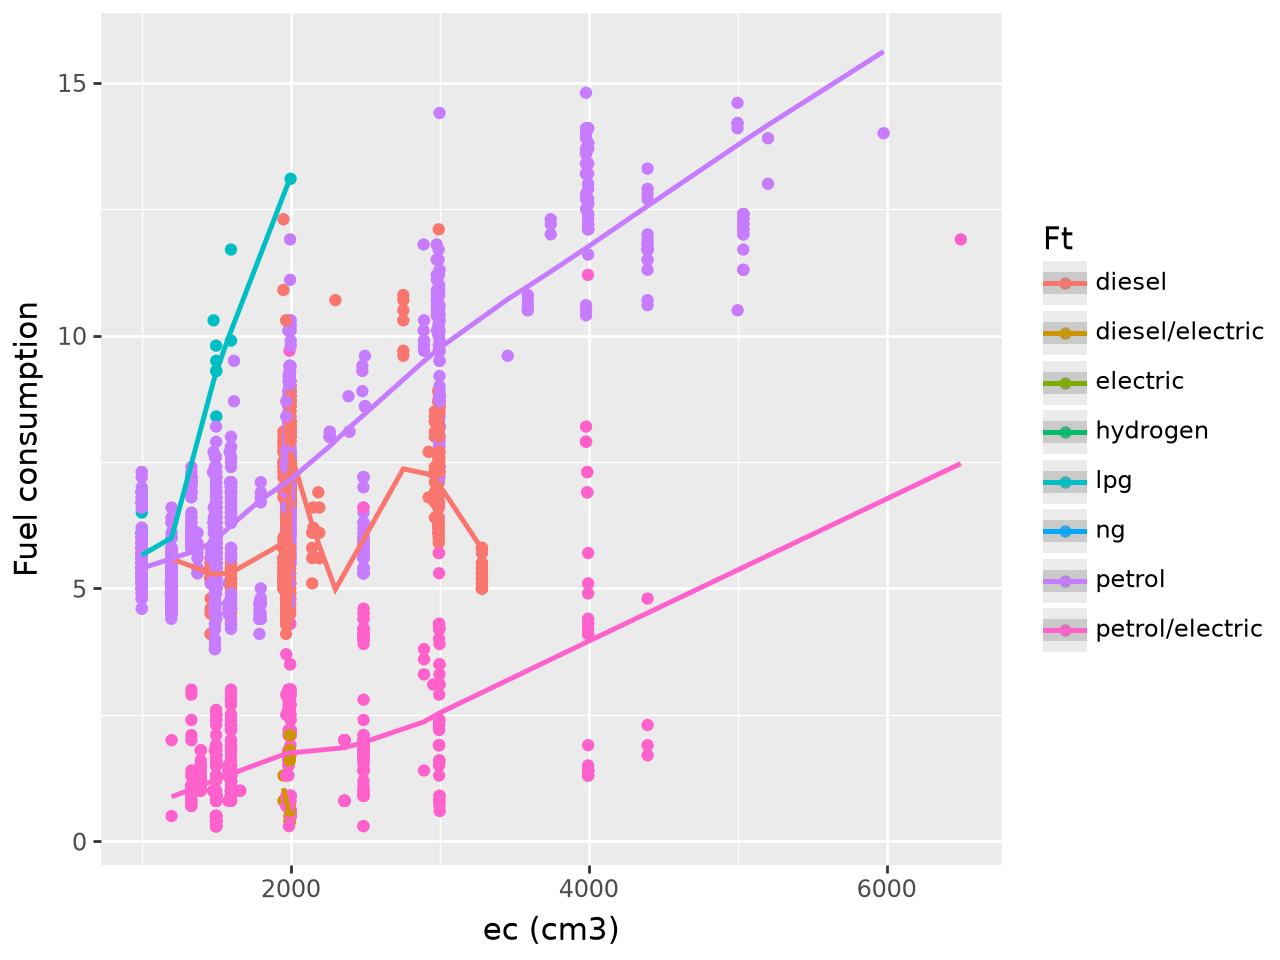

In [9]:
(
    ggplot(df)  # What data to use
    + aes(x = 'ec (cm3)', 
          y = 'Fuel consumption',
         color = 'Ft')  # What variable to use
    + geom_point()   # Geometric object to use for drawing
    + geom_smooth(method = 'lowess')
)

## Relación peso y tamaño de motor, con escala de color para emisiones CO2 (wltp)

/home/pedro/Escritorio/UCM_2026/entorno_julio/lib/python3.12/site-packages/plotnine/layer.py:374: PlotnineWarning: geom_point : Removed 899 rows containing missing values.


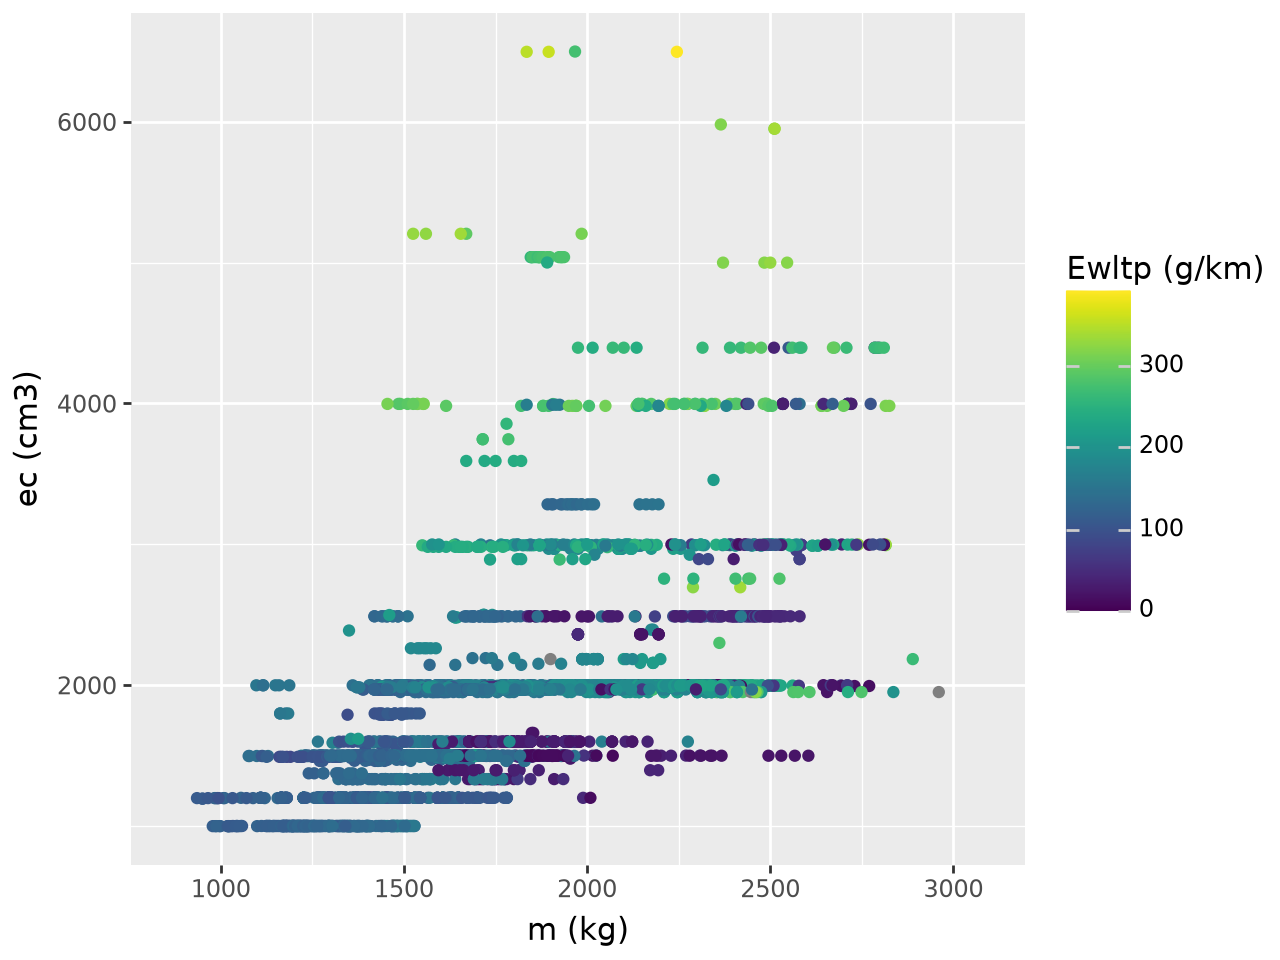

In [10]:
(
    ggplot(df)  # What data to use
    + aes(x = 'm (kg)', 
          y = 'ec (cm3)',
         color = 'Ewltp (g/km)')  # What variable to use
    +  geom_point()   # Geometric object to use for drawing
)

## Relación peso y consumo por tipo de motor

/home/pedro/Escritorio/UCM_2026/entorno_julio/lib/python3.12/site-packages/plotnine/stats/smoothers.py:342: PlotnineWarning: Confidence intervals are not yet implemented for lowess smoothings.
/home/pedro/Escritorio/UCM_2026/entorno_julio/lib/python3.12/site-packages/plotnine/layer.py:374: PlotnineWarning: geom_point : Removed 1664 rows containing missing values.


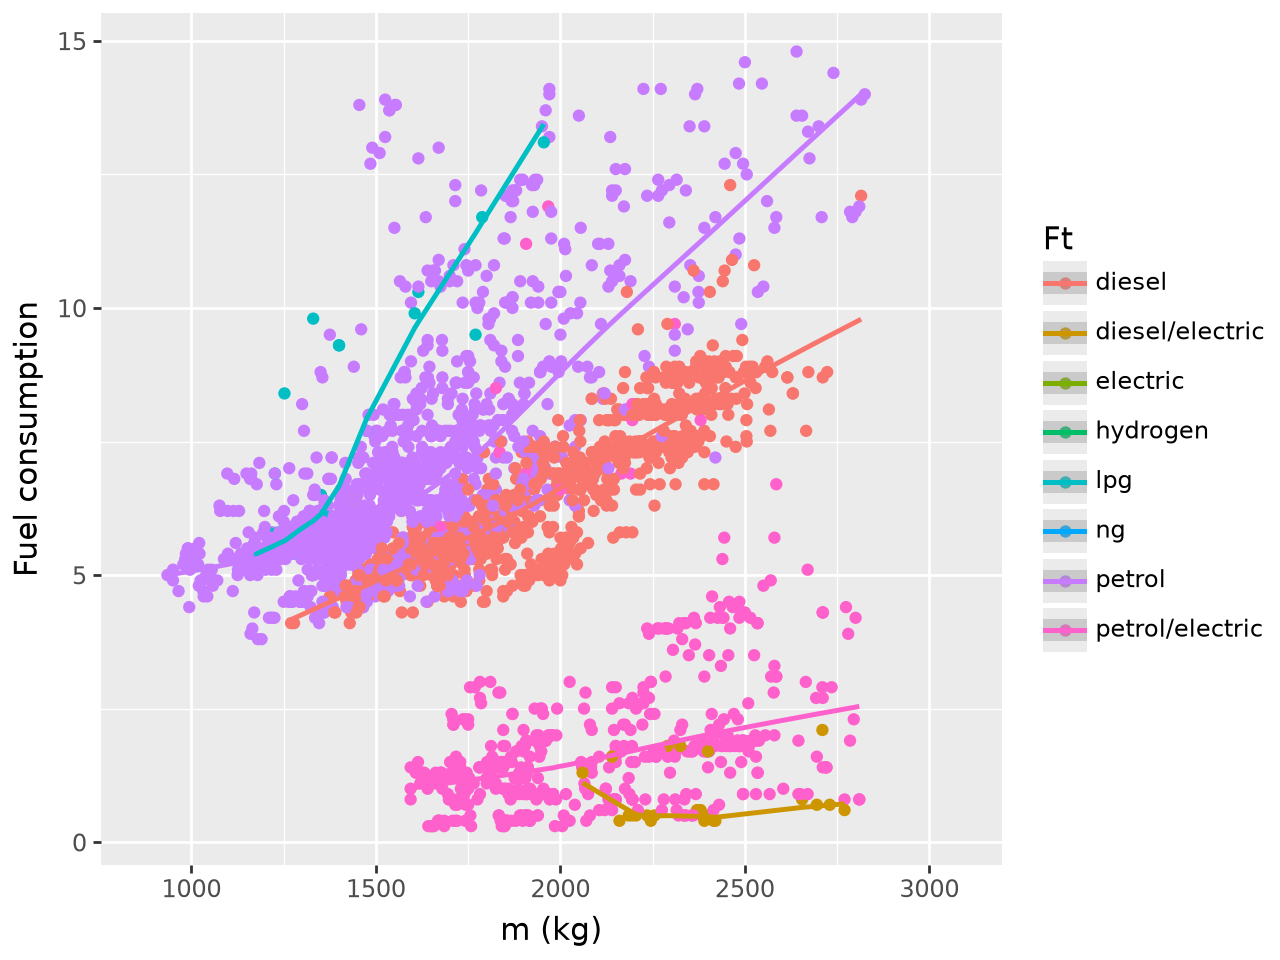

In [11]:
(
    ggplot(df)  # What data to use
    + aes(x = 'm (kg)', 
          y = 'Fuel consumption',
         color = 'Ft')  # What variable to use
    + geom_point()
    + geom_smooth(method = 'lowess') 
#    + geom_smooth(method = 'lm')# Geometric object to use for drawing
)

## (como en 2016) Relación tamaño de motor y consumo por tipo de motor

/home/pedro/Escritorio/UCM_2026/entorno_julio/lib/python3.12/site-packages/plotnine/stats/smoothers.py:342: PlotnineWarning: Confidence intervals are not yet implemented for lowess smoothings.
/home/pedro/Escritorio/UCM_2026/entorno_julio/lib/python3.12/site-packages/statsmodels/nonparametric/smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
/home/pedro/Escritorio/UCM_2026/entorno_julio/lib/python3.12/site-packages/plotnine/layer.py:374: PlotnineWarning: geom_point : Removed 1664 rows containing missing values.


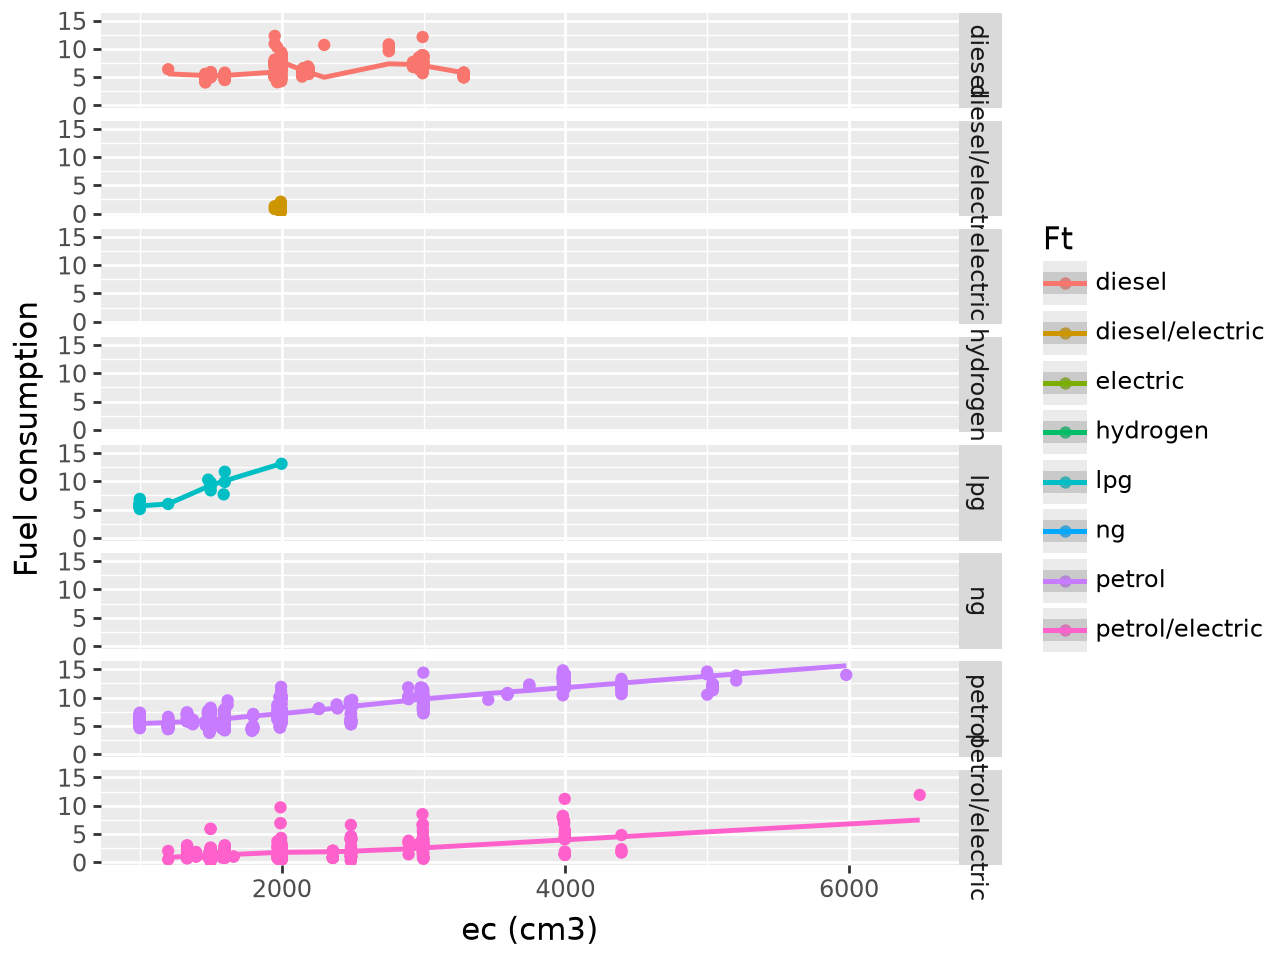

In [12]:
(
    ggplot(df)  # What data to use
    + aes(x = 'ec (cm3)', 
          y = 'Fuel consumption',
         color = 'Ft')  # What variable to use
    + geom_point()
    + geom_smooth(method = 'lowess') 
    + facet_grid(rows = 'Ft')
)

In [13]:
g = (
    ggplot(df)  # What data to use
    + aes(x = 'm (kg)', 
          y = 'Ewltp (g/km)',
         color = 'Ft')  # What variable to use
    + geom_point()
    + geom_smooth(method = 'lowess') 
#    + facet_grid(rows = 'Ct')
)

/home/pedro/Escritorio/UCM_2026/entorno_julio/lib/python3.12/site-packages/plotnine/stats/smoothers.py:342: PlotnineWarning: Confidence intervals are not yet implemented for lowess smoothings.
/home/pedro/Escritorio/UCM_2026/entorno_julio/lib/python3.12/site-packages/plotnine/stats/stat_smooth.py:213: PlotnineWarning: Smoothing requires 2 or more points. Got 1. Not enough points for smoothing. If this message a surprise, make sure the column mapped to the x aesthetic has the right dtype.
/home/pedro/Escritorio/UCM_2026/entorno_julio/lib/python3.12/site-packages/plotnine/stats/smoothers.py:342: PlotnineWarning: Confidence intervals are not yet implemented for lowess smoothings.
/home/pedro/Escritorio/UCM_2026/entorno_julio/lib/python3.12/site-packages/plotnine/layer.py:374: PlotnineWarning: geom_point : Removed 4 rows containing missing values.


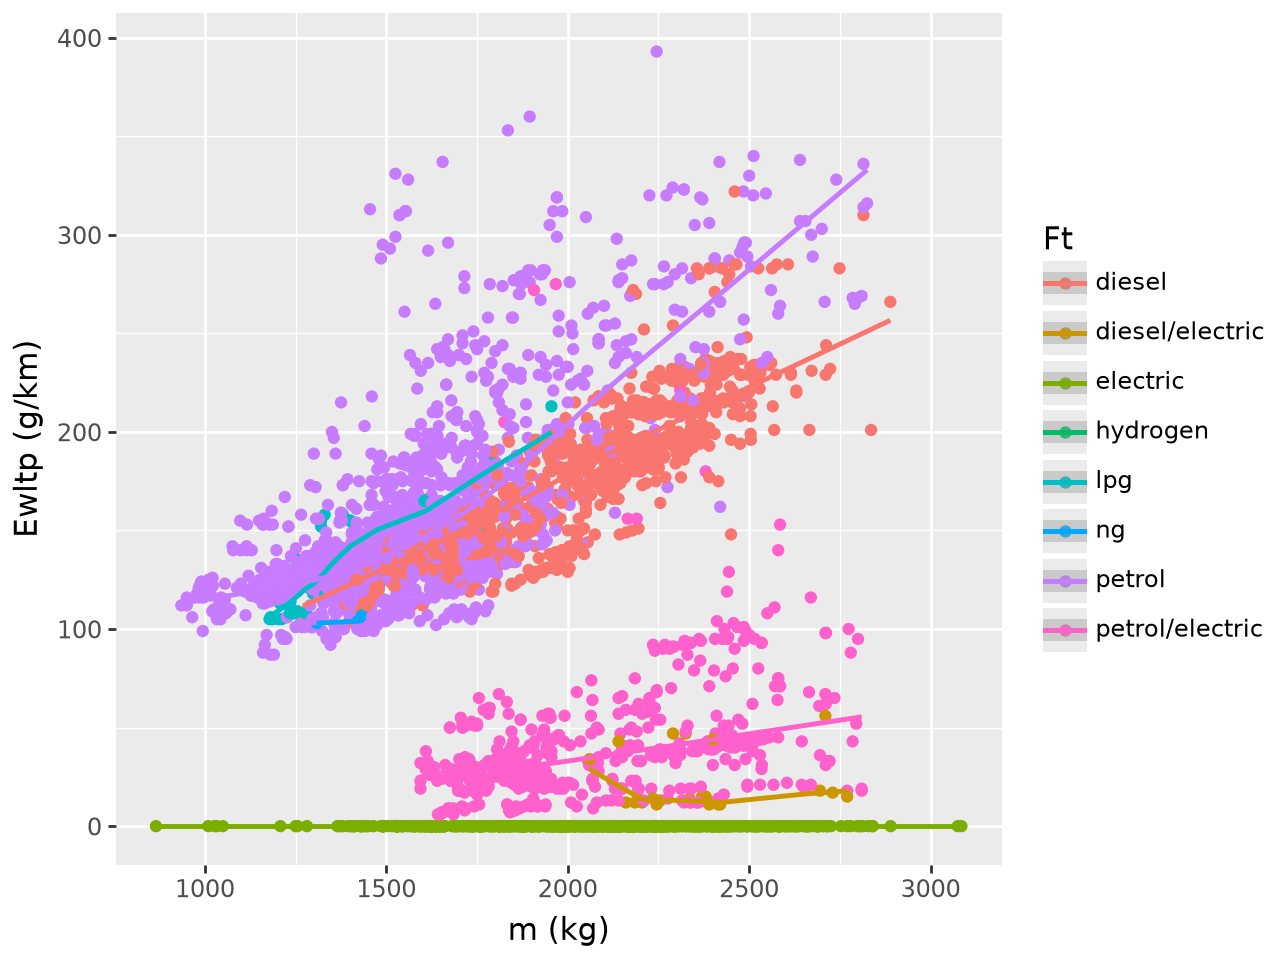

In [14]:
g

In [15]:
g = g + theme(figure_size=(12, 12))

In [16]:
g.save("scatter_CO2_2025.png", dpi = 300)

/home/pedro/Escritorio/UCM_2026/entorno_julio/lib/python3.12/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 12 x 12 in image.
/home/pedro/Escritorio/UCM_2026/entorno_julio/lib/python3.12/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: scatter_CO2_2025.png
/home/pedro/Escritorio/UCM_2026/entorno_julio/lib/python3.12/site-packages/plotnine/stats/smoothers.py:342: PlotnineWarning: Confidence intervals are not yet implemented for lowess smoothings.
/home/pedro/Escritorio/UCM_2026/entorno_julio/lib/python3.12/site-packages/plotnine/stats/stat_smooth.py:213: PlotnineWarning: Smoothing requires 2 or more points. Got 1. Not enough points for smoothing. If this message a surprise, make sure the column mapped to the x aesthetic has the right dtype.
/home/pedro/Escritorio/UCM_2026/entorno_julio/lib/python3.12/site-packages/plotnine/stats/smoothers.py:342: PlotnineWarning: Confidence intervals are not yet implemented for lowess smoothings.
/home/pedro/Escritorio/UCM